In [1]:
from glob import glob
import numpy as np
from scipy.spatial.transform import Rotation
from scipy.optimize import linear_sum_assignment
import matplotlib.pyplot as plt
np.set_printoptions(suppress=True)

In [217]:
a_length = 1.0
b_length = 1.12
c_length = 1.5

angle_ab = 95.0
angle_ac = 90.0

a = np.array([1.0,0,0]) * a_length
b = np.array([1.0,0,0]) * b_length
c = np.array([1.0,0,0]) * c_length

b = Rotation.from_euler('xyz', [0,0,angle_ab], degrees=True).apply(b)
c = Rotation.from_euler('xyz', [0,angle_ac,0], degrees=True).apply(c)

def create_lattice(a, b, c, lattice_size = 3):
    lattice = np.empty(((lattice_size*2-1)**3, 3))
    for h in range(-lattice_size + 1, lattice_size):
        for k in range(-lattice_size + 1, lattice_size):
            for l in range(-lattice_size + 1, lattice_size):
                lattice[(h + lattice_size - 1) + (k + lattice_size - 1) * (2*lattice_size - 1) + (l + lattice_size - 1) * (2*lattice_size - 1)**2] = a*h + b*k + c*l
    return lattice

lattice = create_lattice(a, b, c, lattice_size=3)

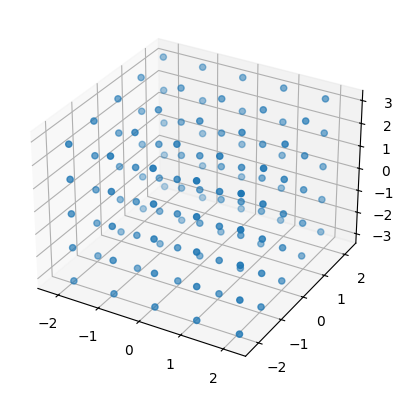

In [109]:
fig, ax = plt.subplots(1, 1, subplot_kw={'projection': '3d'})
ax.scatter(lattice[:, 0], lattice[:, 1], lattice[:, 2])

In [110]:
def angle_between(vec_a, vec_b):
    norm_vec_a = np.linalg.norm(vec_a)
    norm_vec_b = np.linalg.norm(vec_b)
    dot_ab = np.dot(vec_a, vec_b)
    if norm_vec_a < 1e-6 or norm_vec_b < 1e-6 or abs(dot_ab - np.pi) < 1e-6:
        return 0
    return np.arccos(np.clip(dot_ab/(norm_vec_a*norm_vec_b), -1.0, 1.0))

In [111]:
min_angle = np.pi/4
def calc_angles(lattice, min_angle = np.pi/4):
    lattice_vec_ang = list()
    lattice_indices = list()
    for i in range(lattice.shape[0]):
        for j in range(i + 1, lattice.shape[0]):
            ang = angle_between(lattice[i], lattice[j])
            if not abs(ang) < min_angle and not abs(ang - np.pi) < min_angle:
                lattice_indices.append((i,j))
                lattice_vec_ang.append([
                    np.linalg.norm(lattice[i]),
                    np.linalg.norm(lattice[j]),
                    ang
                ])
    lattice_vec_ang = np.array(lattice_vec_ang)
    lattice_indices = np.array(lattice_indices)
    return lattice_vec_ang, lattice_indices
lattice_vec_ang, lattice_indices = calc_angles(lattice)

In [132]:
prob_dist = 1/np.linalg.norm(lattice_vec_ang[:, :2], axis=1)**4
prob_dist /= prob_dist.sum()
selected = np.random.choice(np.arange(lattice_vec_ang.shape[0]), 10, replace=False, p=prob_dist)
samples = lattice_vec_ang[selected]
annotations = samples

## Concept Description

Create a cell of $a$, $b$ and $c$ where $a$ and $b$ are selected vectors of minimal length and $c$ is a vector with a projected part onto the span of $a$ and $b$ and the height of the scalar projection is defined by the size of the cell $\det{a  b c}$

Create the grid using $a$, $b$, $c$ and calculate the angles between all vectors in the grid along with their lenght and angles $G = (\overline{a}, \overline{b}, \angle ab)$. 

Calculate the cost minimal linear sum assigment between all annotated values and all tuples in $G$

In [224]:
EPS = 1e-6

unit_a = np.array([1.0, 0, 0])
unit_b = np.array([0, 1.0, 0])
unit_c = np.cross(unit_a, unit_b)

lattice = create_lattice(unit_a, unit_b, unit_c)
lattice_vec_ang = list()
lattice_indices = list()
for i in range(lattice.shape[0]):
    for j in range(i + 1, lattice.shape[0]):
        ang = angle_between(lattice[i], lattice[j])
        if not abs(ang) < min_angle and not abs(ang - np.pi) < min_angle:
            lattice_indices.append((i,j))
            lattice_vec_ang.append([
                np.linalg.norm(lattice[i]),
                np.linalg.norm(lattice[j]),
                ang
            ])
lattice_vec_ang = np.array(lattice_vec_ang)
cost_matrix = np.zeros((annotations.shape[0], lattice_vec_ang.shape[0]))
for i in range(annotations.shape[0]):
    cost_matrix[i] = np.linalg.norm(annotations[i] - lattice_vec_ang, axis=1)
row_ind, col_ind = linear_sum_assignment(cost_matrix)
cost_sum = cost_matrix[row_ind, col_ind].sum()
print(cost_sum)

0.0


In [135]:
def calc_cost(base_a, base_b, base_c, min_angle=np.pi/4, max_distance=None):
    lattice = create_lattice(base_a, base_b, base_c)
    if max_distance:
        lattice = lattice[np.linalg.norm(lattice, axis=1) < max_distance]
    lattice_vec_ang, _ = calc_angles(lattice, min_angle=min_angle)
    cost_matrix = np.zeros((annotations.shape[0], lattice_vec_ang.shape[0]))
    for i in range(annotations.shape[0]):
        cost_matrix[i] = np.linalg.norm(annotations[i] - lattice_vec_ang, axis=1)
    row_ind, col_ind = linear_sum_assignment(cost_matrix)
    cost_sum = cost_matrix[row_ind, col_ind].sum()
    return cost_sum

In [137]:
calc_cost(unit_a, unit_b, unit_c) #, min_angle=(annotations[:, 2].min() - EPS), max_distance=(annotations[:,:2].max() + EPS))

np.float64(0.0)

In [ ]:
annotation_lengths = np.concatenate([annotations[:, 0], annotations[:, 1]])
candidate_ind = np.argmin(annotation_lengths) % annotations.shape[0]

candidate_a = np.array([annotations[candidate_ind, 0] ,0,0])
candidate_b = Rotation.from_euler('xyz', [0,0,annotations[candidate_ind, 2]], degrees=False).apply(np.array([1.0,0,0])) * annotations[candidate_ind, 1]

orth_vec = np.cross(candidate_a, candidate_b)
orth_vec /= np.linalg.norm(orth_vec)

array([0., 0., 1.])

In [195]:
def calc_fac_orth(fac_a, fac_b, base_a, base_b, base_orth, length):
    assert length >= 0
    a = np.sum(base_orth**2)
    b = 2 * (fac_a * np.sum(base_a * base_orth) + fac_b * np.sum(base_b * base_orth))
    c = fac_a**2 * np.sum(base_a**2) + fac_b**2 * np.sum(base_b**2) - length**2
    det = b**2 - 4*a*c
    if det < 0:
        return None, None
    return [(-b + np.sqrt(det))/(2*a), (-b - np.sqrt(det))/(2*a)]


fac_a = 0.0
fac_b = 0.5
fac_orth, _ = calc_fac_orth(fac_a, fac_b, candidate_a, candidate_b, orth_vec, 4.0)

candidate_c = candidate_a * fac_a + candidate_b * fac_b + orth_vec * fac_orth
candidate_c

array([-0.04357787,  0.90033381,  3.89711432])

In [222]:
space_fac_a = np.linspace(0, 1, 10)
space_fac_b = np.linspace(0, 1, 10)
space_vec_length = np.linspace(annotations[:, :2].min(), annotations[:, :2].max(), 10)

cost_values = np.ones(space_fac_a.shape[0] * space_fac_b.shape[0] * space_vec_length.shape[0]) * np.inf

for i, fac_a in enumerate(space_fac_a):
    for j, fac_b in enumerate(space_fac_b):
        for k, vector_length in enumerate(space_vec_length):
            fac_orth, _ = calc_fac_orth(fac_a, fac_b, candidate_a, candidate_b, orth_vec, vector_length)
            if fac_orth is not None:
                candidate_c = candidate_a * fac_a + candidate_b * fac_b + orth_vec * fac_orth
                cost_values[k + j * space_vec_length.shape[0] + i * space_fac_b.shape[0] * space_vec_length.shape[0]] = calc_cost(candidate_a, candidate_b, candidate_c, min_angle=(annotations[:, 2].min() - 1e-3), max_distance=(annotations[:,:2].max() + 1e-3))

In [223]:
cost_values.min()

np.float64(2.0145795652771037)

In [202]:
ind = np.argmin(cost_values)
fac_a = space_fac_a[ind // (space_vec_length.shape[0] * space_fac_b.shape[0])]
fac_b = space_fac_b[ind % (space_vec_length.shape[0] * space_fac_b.shape[0]) // space_vec_length.shape[0]]
vector_length = space_vec_length[ind % space_vec_length.shape[0]]
fac_orth, _ = calc_fac_orth(fac_a, fac_b, candidate_a, candidate_b, orth_vec, vector_length)

candidate_c = candidate_a * fac_a + candidate_b * fac_b + orth_vec * fac_orth

In [216]:
np.linalg.norm(candidate_c)

np.float64(0.9927429690936285)

In [ ]:
from scipy.spatial import Delaunay

# Generate a set of random 2D points
points = np.random.rand(10, 2)

tri = Delaunay(points)

print("Delaunay simplices (triangles):")
print(tri.simplices)

# Access the points
print("\nInput points:")
print(tri.points)

Delaunay simplices (triangles):
[[6 4 0]
 [4 5 2]
 [6 5 4]
 [5 6 9]
 [5 3 2]
 [3 8 2]
 [1 5 9]
 [3 1 9]
 [1 3 5]
 [3 7 8]
 [6 7 9]
 [7 3 9]]

Input points:
[[0.16697075 0.80349038]
 [0.63877295 0.21475969]
 [0.98305867 0.07755842]
 [0.69738523 0.09866728]
 [0.74250921 0.90004659]
 [0.71720909 0.41034676]
 [0.25980672 0.4978783 ]
 [0.44146189 0.26037739]
 [0.82569485 0.00255457]
 [0.53963618 0.26234748]]


In [21]:
def calculate_cell(annotations):
    annotation_lengths = np.concatenate([annotations[:, 0], annotations[:, 1]])
    candidate_ind = np.argmin(annotation_lengths) % annotations.shape[0]

    candidate_a = np.array([annotations[candidate_ind, 0] ,0,0])
    candidate_b = Rotation.from_euler('xyz', [0,0,annotations[candidate_ind, 2]], degrees=False).apply(np.array([1.0,0,0])) * annotations[candidate_ind, 1]

    orth_vec = np.cross(candidate_a, candidate_b)
    orth_vec /= np.linalg.norm(orth_vec)

    space_fac_a = np.linspace(0, 1, 10)
    space_fac_b = np.linspace(0, 1, 10)
    space_fac_orth = np.linspace(0, 1, 10)

    cost_values = np.empty(space_fac_a.shape[0] * space_fac_b.shape[0] * space_fac_orth.shape[0])

    for i, fac_a in enumerate(space_fac_a):
        for j, fac_b in enumerate(space_fac_b):
            for k, fac_orth in enumerate(space_fac_orth):
                candidate_c = candidate_a * fac_a + candidate_b * fac_b + orth_vec * fac_orth
                cost_values[k + j * space_fac_orth.shape[0] + i * space_fac_b.shape[0] * space_fac_orth.shape[0]] = calc_cost(candidate_a, candidate_b, candidate_c, min_angle=(annotations[:, 2].min() - 1e-3), max_distance=(annotations[:,:2].max() + 1e-3))

    base_a = candidate_a
    base_b = candidate_b
    base_c = candidate_a * fac_a + candidate_b * fac_b + orth_vec * fac_orth

    return base_a, base_b, base_c

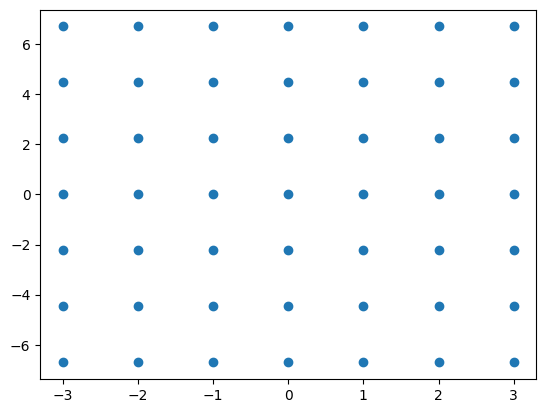

In [22]:
lattice = list()
for i in range(-3,4):
    for j in range(-3,4):
        lattice.append(i*candidate_a + j*candidate_b)
lattice = np.array(lattice)

plt.scatter(lattice[:, 0], lattice[:, 1])

In [26]:
candidate_a

array([1., 0., 0.])